# Preparation

### Pengumpulan dataset

In [94]:
import pandas as pd

# Mendefinisikan path file
file_dataset = r'D:\TUGAS AKHIR\Dataset\dataset_phishing.csv'

# Memuat dataset
df = pd.read_csv(file_dataset)


### Analisis dataset

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Informasi Dasar Dataset
# Menampilkan daftar 89 kolom
print(f"Dataset memiliki {df.shape[1]} kolom.\n")

with pd.option_context('display.max_rows', None):
    print(df.dtypes)

Dataset memiliki 89 kolom.

url                            object
length_url                      int64
length_hostname                 int64
ip                              int64
nb_dots                         int64
nb_hyphens                      int64
nb_at                           int64
nb_qm                           int64
nb_and                          int64
nb_or                           int64
nb_eq                           int64
nb_underscore                   int64
nb_tilde                        int64
nb_percent                      int64
nb_slash                        int64
nb_star                         int64
nb_colon                        int64
nb_comma                        int64
nb_semicolumn                   int64
nb_dollar                       int64
nb_space                        int64
nb_www                          int64
nb_com                          int64
nb_dslash                       int64
http_in_path                    int64
https_token           

In [97]:
# 2. Pengecekan Kualitas Data (Data Cleaning)
# Mengecek Missing Values (Data yang kosong)
print("--- Mengecek Missing Values ---")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Tidak ada data yang kosong di seluruh 89 kolom.")
else:
    print("Kolom dengan data kosong:")
    print(missing[missing > 0])

--- Mengecek Missing Values ---
Tidak ada data yang kosong di seluruh 89 kolom.


In [98]:

# Mengecek Baris Duplikat pada Kolom Url

nama_kolom = 'url'

# Mencari semua baris yang memiliki URL duplikat
# keep=False artinya semua baris yang sama akan ditampilkan (bukan cuma salah satu)
df_duplikat_url = df[df[nama_kolom].duplicated(keep=False)]

# 3. Menampilkan hasil analisis
print(f"--- Mengecek Duplikat Kolom: {nama_kolom} ---")
print(f"Total baris yang terindikasi duplikat: {len(df_duplikat_url)}")

if len(df_duplikat_url) > 0:
    print("\n--- Daftar URL yang duplikat dan jumlah kemunculannya ---")
    print(df_duplikat_url[nama_kolom].value_counts())
    
    # Menampilkan 5 contoh data duplikat pertama (beserta kolom lainnya)
    print("\n--- Pratinjau Data Duplikat (5 baris pertama) ---")
    display(df_duplikat_url.head(5))
else:
    print("\nSelamat! Tidak ada baris duplikat pada kolom URL.")


--- Mengecek Duplikat Kolom: url ---
Total baris yang terindikasi duplikat: 2

--- Daftar URL yang duplikat dan jumlah kemunculannya ---
url
http://e710z0ear.du.r.appspot.com/c:/users/user/downlo    2
Name: count, dtype: int64

--- Pratinjau Data Duplikat (5 baris pertama) ---


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,nb_eq,nb_underscore,nb_tilde,nb_percent,nb_slash,nb_star,nb_colon,nb_comma,nb_semicolumn,nb_dollar,nb_space,nb_www,nb_com,nb_dslash,http_in_path,https_token,ratio_digits_url,ratio_digits_host,punycode,port,tld_in_path,tld_in_subdomain,abnormal_subdomain,nb_subdomains,prefix_suffix,random_domain,shortening_service,path_extension,nb_redirection,nb_external_redirection,length_words_raw,char_repeat,shortest_words_raw,shortest_word_host,shortest_word_path,longest_words_raw,longest_word_host,longest_word_path,avg_words_raw,avg_word_host,avg_word_path,phish_hints,domain_in_brand,brand_in_subdomain,brand_in_path,suspecious_tld,statistical_report,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,ratio_nullHyperlinks,nb_extCSS,ratio_intRedirection,ratio_extRedirection,ratio_intErrors,ratio_extErrors,login_form,external_favicon,links_in_tags,submit_email,ratio_intMedia,ratio_extMedia,sfh,iframe,popup_window,safe_anchor,onmouseover,right_clic,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
6035,http://e710z0ear.du.r.apps...,62,26,0,4,0,0,0,0,0,0,0,0,0,6,0,2,0,0,0,0,0,0,0,0,1,0.064516,0.153846,0,0,0,0,0,3,0,0,1,0,0,0,8,2,1,1,1,14,9,14,5.375,4.75,6.0,0,0,0,0,0,0,21,0.190476,0.809524,0,1,0,0.294118,0,0.0,0,1,0.0,0,20.0,80.0,0,0,0,25.0,0,0,0,1,1,0,217,5627,0,0,1,5,phishing
11305,http://e710z0ear.du.r.apps...,54,26,0,4,0,0,0,0,0,0,0,0,0,6,0,2,0,0,0,0,0,0,0,0,1,0.074074,0.153846,0,0,0,0,0,3,0,0,1,0,0,0,8,1,1,1,1,9,9,6,4.375,4.75,4.0,0,0,0,0,0,0,21,0.190476,0.809524,0,1,0,0.176471,0,0.0,0,1,0.0,0,20.0,80.0,0,0,0,25.0,0,0,0,1,1,0,230,5614,0,0,1,5,phishing



--- Distribusi Kelas (status) ---
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20932\399458916.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, palette='viridis')


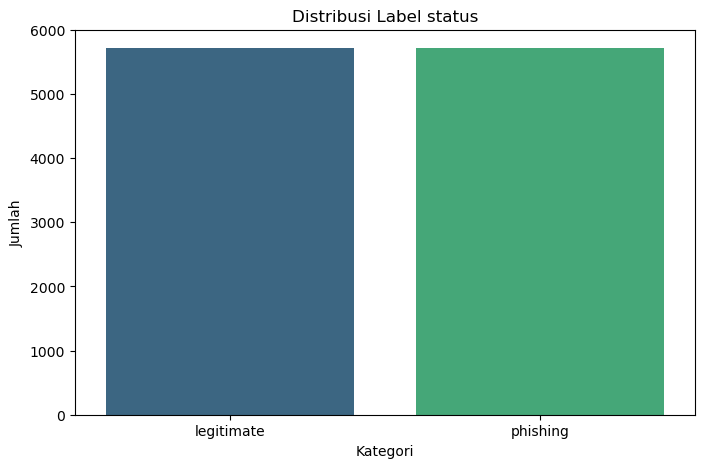

In [99]:
# Analisis Target (Label)
# Asumsi kolom target bernama 'status' atau 'label'. 
target_col = 'status'
if target_col in df.columns:
    print(f"\n--- Distribusi Kelas ({target_col}) ---")
    print(df[target_col].value_counts())
    
    # Visualisasi Distribusi Target
    plt.figure(figsize=(8, 5))
    sns.countplot(x=target_col, data=df, palette='viridis')
    plt.title(f'Distribusi Label {target_col}')
    plt.ylabel('Jumlah')
    plt.xlabel('Kategori')
    plt.show()
else:
    print(f"\nKolom '{target_col}' tidak ditemukan. Cek kembali nama kolom target.")


--- Heatmap Korelasi ---


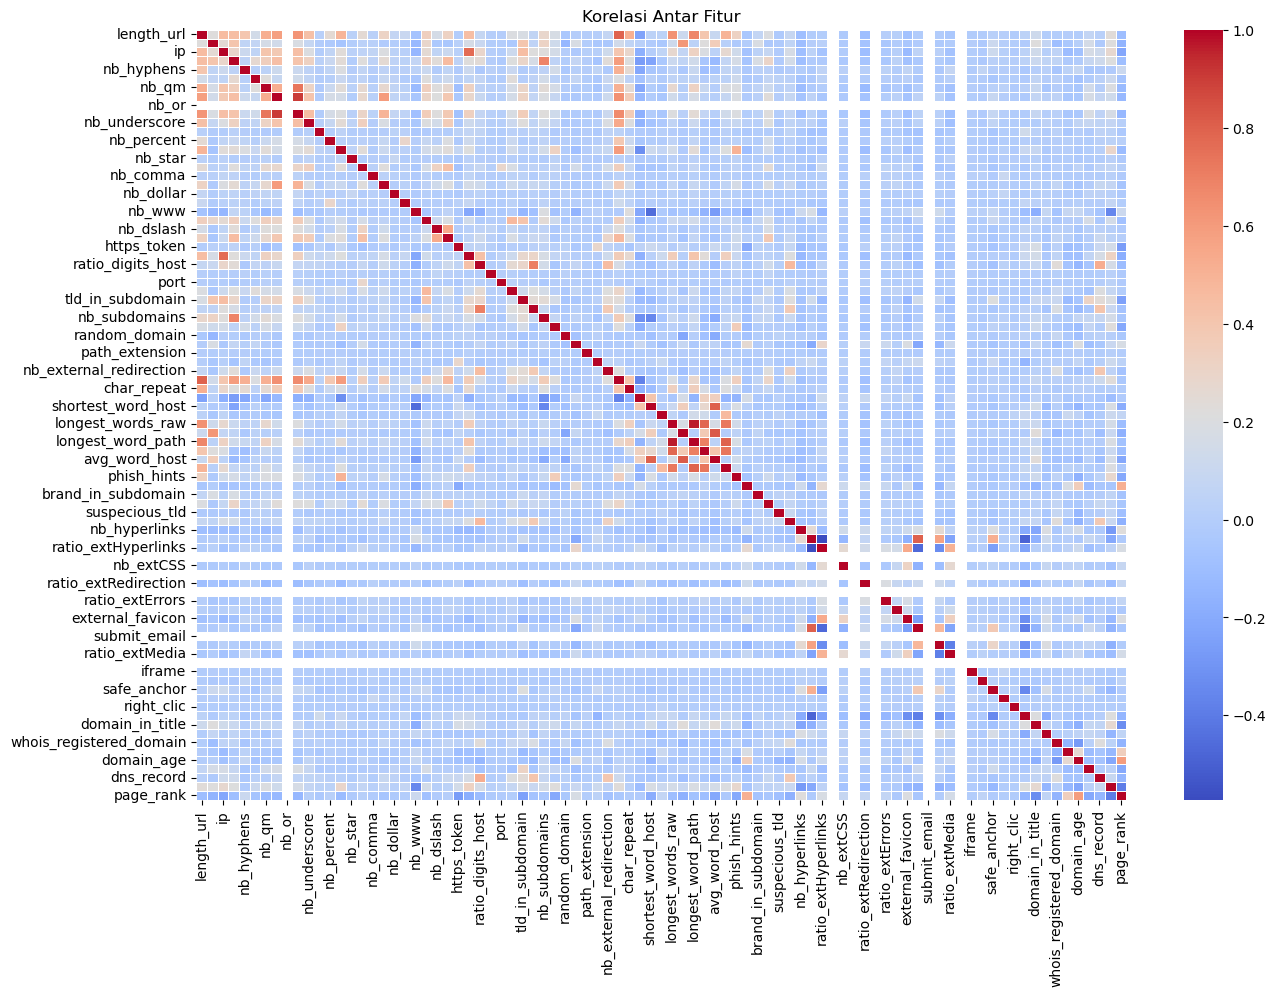

In [100]:
# Analisis Korelasi (Hanya untuk fitur numerik)
print("\n--- Heatmap Korelasi ---")
plt.figure(figsize=(15, 10))
# Memilih hanya kolom numerik untuk korelasi
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Korelasi Antar Fitur')
plt.show()

# Preprocessing

### Data Selection

In [101]:
# List kolom yang tidak digunakan
kolom_yang_dihapus = [
    'nb_or', 
    'ratio_nullHyperlinks', 
    'ratio_intRedirection', 
    'ratio_intErrors', 
    'submit_email', 
    'sfh'
]

# Melakukan drop column
# errors='ignore' digunakan agar kode tidak berhenti jika nama kolom ada yang sedikit berbeda (huruf besar/kecil)
df_selected = df.drop(columns=kolom_yang_dihapus, errors='ignore')

# Menampilkan informasi dataset setelah seleksi
print("--- Tahap Data Selection Selesai ---")
print(f"Jumlah kolom awal : {df.shape[1]}")
print(f"Jumlah kolom dihapus : {len(kolom_yang_dihapus)}")
print(f"Jumlah kolom sekarang : {df_selected.shape[1]}")

# Menampilkan 5 baris pertama dataset hasil seleksi
display(df_selected.head())

--- Tahap Data Selection Selesai ---
Jumlah kolom awal : 89
Jumlah kolom dihapus : 6
Jumlah kolom sekarang : 83


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_eq,nb_underscore,nb_tilde,nb_percent,nb_slash,nb_star,nb_colon,nb_comma,nb_semicolumn,nb_dollar,nb_space,nb_www,nb_com,nb_dslash,http_in_path,https_token,ratio_digits_url,ratio_digits_host,punycode,port,tld_in_path,tld_in_subdomain,abnormal_subdomain,nb_subdomains,prefix_suffix,random_domain,shortening_service,path_extension,nb_redirection,nb_external_redirection,length_words_raw,char_repeat,shortest_words_raw,shortest_word_host,shortest_word_path,longest_words_raw,longest_word_host,longest_word_path,avg_words_raw,avg_word_host,avg_word_path,phish_hints,domain_in_brand,brand_in_subdomain,brand_in_path,suspecious_tld,statistical_report,nb_hyperlinks,ratio_intHyperlinks,ratio_extHyperlinks,nb_extCSS,ratio_extRedirection,ratio_extErrors,login_form,external_favicon,links_in_tags,ratio_intMedia,ratio_extMedia,iframe,popup_window,safe_anchor,onmouseover,right_clic,empty_title,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com...,37,19,0,3,0,0,0,0,0,0,0,0,3,0,1,0,0,0,0,1,0,0,0,1,0.000000,0.0,0,0,0,0,0,3,0,0,0,0,0,0,4,4,3,3,3,11,11,6,5.750000,7.0,4.500000,0,0,0,0,0,0,17,0.529412,0.470588,0,0.875000,0.500000,0,0,80.000000,100.000000,0.000000,0,0,0.0,0,0,0,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology...,77,23,1,1,0,0,0,0,0,0,0,0,5,0,1,0,0,0,0,0,0,0,0,1,0.220779,0.0,0,0,0,0,0,1,0,0,0,0,1,0,4,4,2,19,2,32,19,32,15.750000,19.0,14.666667,0,0,0,0,0,0,30,0.966667,0.033333,0,0.000000,0.000000,0,0,100.000000,80.000000,20.000000,0,0,100.0,0,0,0,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.co...,126,50,1,4,1,0,1,2,3,2,0,0,5,0,1,0,0,0,0,0,1,0,0,0,0.150794,0.0,0,0,0,1,0,3,1,0,0,0,1,0,12,2,2,3,2,17,13,17,8.250000,8.4,8.142857,0,0,0,0,0,0,4,1.000000,0.000000,0,0.000000,0.000000,0,0,100.000000,0.000000,0.000000,0,0,100.0,0,0,0,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,1,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,1,0,5,5,0,5,5,0,5.000000,5.0,0.000000,0,0,0,0,0,0,149,0.973154,0.026846,0,0.250000,0.250000,0,0,100.000000,96.428571,3.571429,0,0,62.5,0,0,0,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tra...,55,15,0,2,2,0,0,0,0,0,0,0,5,0,1,0,0,0,0,1,0,0,0,1,0.000000,0.0,0,0,0,0,0,2,0,0,0,0,1,0,6,3,3,3,4,11,7,11,6.333333,5.0,7.000000,0,0,0,0,0,0,102,0.470588,0.529412,0,0.537037,0.018519,1,0,76.470588,0.000000,100.000000,0,0,0.0,0,0,0,0,1,0,224,8175,8725,0,0,6,legitimate


### Feature Engineering

In [102]:
from urllib.parse import urlparse
import pandas as pd
import re

# 1. Fungsi Parsing (DENGAN NAMA KOLOM UNIK)
def feature_engineering_parsing(url):
    try:
        parsed_url = urlparse(str(url))
        
        features = {
            # --- Komponen Utama (Beri prefix 'parsed_' agar tidak bentrok) ---
            'parsed_protocol': parsed_url.scheme,   # http atau https
            'parsed_netloc': parsed_url.netloc,     # domain + port
            'parsed_domain': parsed_url.hostname,   # nama domain (ex: google.com)
            'parsed_port': parsed_url.port,         # port (jika ada)
            'parsed_path': parsed_url.path,         # struktur folder/file
            'parsed_query': parsed_url.query,       # parameter url
            'parsed_fragment': parsed_url.fragment, # anchor (bagian dari URL yang terletak setelah tanda pagar #)
            
            # Turunan Numerik 
            'len_domain': len(parsed_url.netloc) if parsed_url.netloc else 0,
            'len_path': len(parsed_url.path) if parsed_url.path else 0,
            'is_https': 1 if parsed_url.scheme == 'https' else 0,
            'count_subdomain': len(parsed_url.netloc.split('.')) - 1 if parsed_url.netloc else 0,
            'has_ip': 1 if re.search(r'\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}', str(parsed_url.netloc)) else 0
        }
        return pd.Series(features)
    except:
        return pd.Series({})

# 2. Eksekusi Feature Engineering
print("--- Memproses Feature Engineering ---")

# Terapkan fungsi
df_parsed = df['url'].apply(feature_engineering_parsing)

# Gabungkan dengan dataframe asli
df_final = pd.concat([df, df_parsed], axis=1)

# 3. Menampilkan Hasil (Updated Column Names)
print("\nKOMPONEN STRUKTUR URL")

# Gunakan nama kolom yang sudah diberi prefix 'parsed_'
kolom_parsing = ['url', 'parsed_protocol', 'parsed_netloc', 'parsed_domain', 'parsed_port', 'parsed_path']

display(df_final[kolom_parsing].head(10))

# 4. Cek URL dengan Port Spesifik (FIXED)
print("\nURL dengan Port Spesifik:")

# Filter menggunakan kolom 'parsed_port' yang unik
df_with_port = df_final[df_final['parsed_port'].notna()]

if not df_with_port.empty:
    display(df_with_port[kolom_parsing].head(5))
else:
    print("Tidak ditemukan URL dengan port spesifik.")

--- Memproses Feature Engineering ---

KOMPONEN STRUKTUR URL


,url,parsed_protocol,parsed_netloc,parsed_domain,parsed_port,parsed_path
0,http://www.crestonwood.com...,http,www.crestonwood.com,www.crestonwood.com,NaN,/router.php
1,http://shadetreetechnology...,http,shadetreetechnology.com,shadetreetechnology.com,NaN,/V4/validation/a111aedc8ae...
2,https://support-appleld.co...,https,support-appleld.com.secure...,support-appleld.com.secure...,NaN,/ap/89e6a3b4b063b8d/
3,http://rgipt.ac.in,http,rgipt.ac.in,rgipt.ac.in,NaN,
4,http://www.iracing.com/tra...,http,www.iracing.com,www.iracing.com,NaN,/tracks/gateway-motorsport...
5,http://appleid.apple.com-a...,http,appleid.apple.com-app.es,appleid.apple.com-app.es,NaN,/
6,http://www.mutuo.it,http,www.mutuo.it,www.mutuo.it,NaN,
7,http://www.shadetreetechno...,http,www.shadetreetechnology.com,www.shadetreetechnology.com,NaN,/V4/validation/ba4b8bddd79...
8,http://vamoaestudiarmedici...,http,vamoaestudiarmedicina.blog...,vamoaestudiarmedicina.blog...,NaN,/
9,https://parade.com/425836/...,https,parade.com,parade.com,NaN,/425836/joshwigler/the-ama...



URL dengan Port Spesifik:


,url,parsed_protocol,parsed_netloc,parsed_domain,parsed_port,parsed_path
356,https://monovative-my.shar...,https,monovative-my.sharepoint.c...,monovative-my.sharepoint.com,443.0,/:o:/g/personal/user_monov...
525,https://life4news.ru:443/,https,life4news.ru:443,life4news.ru,443.0,/
857,https://portaal.webreus.nl...,https,portaal.webreus.nl:8080,portaal.webreus.nl,8080.0,
880,http://www.360.ru:80/,http,www.360.ru:80,www.360.ru,80.0,/
1184,https://printexx.ru:443/,https,printexx.ru:443,printexx.ru,443.0,/


### Parsing

In [117]:
import pandas as pd
import re
import numpy as np
from urllib.parse import urlparse
from collections import Counter

# 1. KONFIGURASI
SUSPICIOUS_TLDS = ['tk', 'ml', 'ga', 'cf', 'gq', 'pw', 'top', 'xyz', 'cc', 'ws', 'biz', 'cn', 'ru']
PHISH_HINTS = ['login', 'signin', 'verify', 'update', 'secure', 'account', 'banking', 'confirm', 'bonus', 'free']
BRANDS = ['google', 'paypal', 'microsoft', 'apple', 'facebook', 'netflix', 'amazon', 'yahoo', 'bank', 'whatsapp']

# 2. FUNGSI TRANSFORMASI & HELPER

def get_word_str(text, mode='longest'):
    """Mengambil kata asli dari teks"""
    if not isinstance(text, str): return "Not Found"
    words = re.split(r'\W+', text)
    words = [w for w in words if w]
    if not words: return "Not Found"
    if mode == 'longest': return max(words, key=len)
    if mode == 'shortest': return min(words, key=len)
    return "Not Found"

def get_symbol_str(text, symbol):
    """Mengubah angka hitungan menjadi visual simbol."""
    count = text.count(symbol)
    return symbol * count if count > 0 else "Not Found"

def get_words_from_url(url):
    """Mengambil deretan kata penyusun URL"""
    words = re.split(r'\W+', url)
    words = [w for w in words if w]
    return " ".join(words) if words else "Not Found"

def get_most_repeated_char(url):
    """Mencari karakter yang paling sering muncul"""
    if not url: return "Not Found"
    counts = Counter(url)
    most_common, count = counts.most_common(1)[0]
    return f"Char '{most_common}'"

def simple_domain_extract(url):
    try:
        parsed = urlparse(url)
        netloc = parsed.netloc
        if not netloc: return '', '', ''
        parts = netloc.split('.')
        if len(parts) >= 3:
            return '.'.join(parts[:-2]), parts[-2], parts[-1]
        elif len(parts) == 2:
            return '', parts[0], parts[1]
        return '', parts[0], ''
    except:
        return '', '', ''

def transform_all_cols_to_visual(row):
    new_row = row.copy()
    url = row['url']
    
    try:
        parsed = urlparse(url)
        subdomain, domain, suffix = simple_domain_extract(url)
        full_domain = f"{domain}.{suffix}"
        path_part = parsed.path
        domain_part = parsed.netloc
    except:
        return new_row

    # --- A. FITUR URL & PANJANG ---
    new_row['length_url'] = url
    new_row['length_hostname'] = domain_part 
    
    # --- B. FITUR SIMBOL (Visualisasi) ---
    cols_symbol = {
        'nb_dots': '.', 'nb_hyphens': '-', 'nb_at': '@', 'nb_qm': '?', 
        'nb_and': '&', 'nb_eq': '=', 'nb_underscore': '_', 'nb_tilde': '~', 
        'nb_percent': '%', 'nb_slash': '/', 'nb_star': '*', 'nb_colon': ':', 
        'nb_comma': ',', 'nb_semicolumn': ';', 'nb_dollar': '$', 'nb_space': '%20'
    }
    for col, sym in cols_symbol.items():
        if col in new_row: new_row[col] = get_symbol_str(url, sym)

    new_row['nb_www'] = "www" if "www" in url else "Not Found"
    new_row['nb_com'] = ".com" if ".com" in url else "Not Found"
    new_row['nb_dslash'] = "//" * url.count('//') if "//" in url else "Not Found"

    # --- C. FITUR BOOLEAN / TOKEN ---
    new_row['ip'] = "IP Address" if re.match(r'\d+\.\d+\.\d+\.\d+', domain_part) else "Domain Name"
    new_row['http_in_path'] = "http (path)" if "http" in path_part else "Not Found"
    new_row['https_token'] = "HTTPS" if parsed.scheme == 'https' else "HTTP"
    new_row['punycode'] = "Punycode" if "xn--" in domain_part else "Standard"
    new_row['port'] = f"Port {parsed.port}" if parsed.port else "Default"
    new_row['tld_in_path'] = f".{suffix} (path)" if suffix in path_part and suffix else "Not Found"
    new_row['tld_in_subdomain'] = f".{suffix} (sub)" if suffix in subdomain and suffix else "Not Found"
    new_row['abnormal_subdomain'] = "Abnormal" if re.search(r'(http|www)', subdomain) else "Normal"
    new_row['prefix_suffix'] = "Hyphen-Domain" if '-' in domain_part else "Clean"
    new_row['random_domain'] = "Random Hex" if re.search(r'[0-9a-f]{5,}', domain_part) else "Not Found"
    new_row['shortening_service'] = "Shortener" if re.search(r'bit\.ly|goo\.gl|shorte\.st|tinyurl', domain_part) else "Not Found"
    
    if re.search(r'\.(txt|exe|jar|js|php|html)$', path_part):
        new_row['path_extension'] = re.search(r'\.(txt|exe|jar|js|php|html)$', path_part).group(0) 
    else:
        new_row['path_extension'] = "Not Found"

    # --- D. FITUR KATA (Word Extraction) ---
    new_row['shortest_word_host'] = get_word_str(domain_part, 'shortest')
    new_row['longest_word_host']  = get_word_str(domain_part, 'longest')
    new_row['shortest_word_path'] = get_word_str(path_part, 'shortest')
    new_row['longest_word_path']  = get_word_str(path_part, 'longest')
    new_row['shortest_words_raw'] = get_word_str(url, 'shortest')
    new_row['longest_words_raw']  = get_word_str(url, 'longest')
    
    # --- E. FITUR KHUSUS ---
    new_row['length_words_raw'] = get_words_from_url(url)
    new_row['char_repeat'] = get_most_repeated_char(url)
    
    new_row['nb_redirection'] = "Direct Link" if row['nb_redirection'] == 0 else "Redirects Found"
    new_row['nb_external_redirection'] = "Internal/None" if row['nb_external_redirection'] == 0 else "External Jump"
    new_row['ratio_extRedirection'] = f"{int(row['ratio_extRedirection']*100)}%"
    new_row['ratio_intErrors'] = f"{int(row['ratio_intErrors']*100)}%"

    new_row['nb_hyperlinks'] = "Contains Links" if row['nb_hyperlinks'] > 0 else "No Links"
    new_row['ratio_intHyperlinks'] = f"{int(row['ratio_intHyperlinks']*100)}%"
    new_row['ratio_extHyperlinks'] = f"{int(row['ratio_extHyperlinks']*100)}%"
    new_row['nb_extCSS'] = "External CSS" if row['nb_extCSS'] > 0 else "Internal/None"
    
    new_row['domain_registration_length'] = f"{int(row['domain_registration_length'])} days"
    new_row['domain_age'] = f"{int(row['domain_age'])} days"

    # --- F. AVERAGE & RATIOS ---
    for col in ['avg_words_raw', 'avg_word_host', 'avg_word_path']:
        if col in new_row: new_row[col] = f"{float(row[col]):.1f} avg"
            
    for col in ['ratio_digits_url', 'ratio_digits_host', 'links_in_tags', 'ratio_intMedia', 'ratio_extMedia', 'safe_anchor']:
        if col in new_row: new_row[col] = f"{float(row[col])*100:.0f}%"

    # --- G. HINTS & BRANDS ---
    hints = [h for h in PHISH_HINTS if h in url.lower()]
    new_row['phish_hints'] = "|".join(hints) if hints else "Not Found"
    
    brands_dom = [b for b in BRANDS if b in full_domain]
    new_row['domain_in_brand'] = "|".join(brands_dom) if brands_dom else "Not Found"
    brands_sub = [b for b in BRANDS if b in subdomain]
    new_row['brand_in_subdomain'] = "|".join(brands_sub) if brands_sub else "Not Found"
    brands_path = [b for b in BRANDS if b in path_part]
    new_row['brand_in_path'] = "|".join(brands_path) if brands_path else "Not Found"
    
    new_row['suspecious_tld'] = f".{suffix}" if suffix in SUSPICIOUS_TLDS else "Not Found"

    # --- H. SISA FITUR ---
    if 'nb_subdomains' in new_row: new_row['nb_subdomains'] = f"{int(row['nb_subdomains'])} subdomains"
    
    bool_cols = ['login_form', 'external_favicon', 'iframe', 'popup_window', 'onmouseover', 
                 'right_clic', 'empty_title', 'domain_in_title', 'domain_with_copyright', 
                 'whois_registered_domain', 'dns_record', 'google_index']
    for col in bool_cols:
        if col in new_row: new_row[col] = "Found" if row[col] == 1 else "Not Found"

    if 'web_traffic' in new_row: new_row['web_traffic'] = f"{row['web_traffic']}"
    if 'page_rank' in new_row: new_row['page_rank'] = f"{row['page_rank']}"
    if 'statistical_report' in new_row: new_row['statistical_report'] = "Reported" if row['statistical_report'] == 1 else "Clean"

    return new_row

# 1. Load Dataset
df = pd.read_csv(r'D:\TUGAS AKHIR\Dataset\dataset_phishing.csv')

df_clean = df.drop(columns=[c for c in EXCLUDED_COLS if c in df.columns])

# 2. Proses Transformasi
df_sample = df_clean.head(10).copy() 
df_visual = df_sample.apply(transform_all_cols_to_visual, axis=1)

# Pindahkan kolom 'status' ke paling kanan
cols = [c for c in df_visual.columns if c != 'status'] + ['status']
df_visual = df_visual[cols]

# 3. Output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 10000)
pd.set_option('display.max_colwidth', 30) 
pd.set_option('display.max_rows', None)

print(df_visual.to_string(index=False))

                                                                                                                           url                                                                                                                     length_url                                    length_hostname          ip nb_dots nb_hyphens     nb_at     nb_qm    nb_and     nb_eq nb_underscore  nb_tilde nb_percent nb_slash   nb_star nb_colon  nb_comma nb_semicolumn nb_dollar  nb_space    nb_www    nb_com nb_dslash http_in_path https_token ratio_digits_url ratio_digits_host punycode    port tld_in_path tld_in_subdomain abnormal_subdomain nb_subdomains prefix_suffix random_domain shortening_service path_extension  nb_redirection nb_external_redirection                                                                                                            length_words_raw char_repeat shortest_words_raw shortest_word_host shortest_word_path                longest_words_raw     longest_word_hos

### feature extraction


Hasil Encoding Fitur Kategorikal:


,url,parsed_protocol,parsed_protocol_encoded
0,http://www.crestonwood.com...,http,0
1,http://shadetreetechnology...,http,0
2,https://support-appleld.co...,https,1
3,http://rgipt.ac.in,http,0
4,http://www.iracing.com/tra...,http,0


### Data Transformation

In [ ]:

if df_final['status'].dtype == 'object':
    df_final['status'] = df_final['status'].map({'phishing': 1, 'legitimate': 0})

print("Distribusi Kelas:", df_final['status'].value_counts().to_dict())


display(df_final[['url', 'status']].sample(10).style.hide())

Distribusi Kelas: {0: 5715, 1: 5715}


url,status
http://www.expertsystem.com/10-text-mining-examples/,0
http://paypal.com.0.security-confirmation.3408b8d8a758db7c66b435a2c13352e4.as2.2u.se/,1
https://www.dropbox.com/l/AADF6y5O_I_uxzPM7EarhSzPUoBxa9VQXQ0,1
https://www.lyzovani.cz/default.asp,0
https://www.monistat.com/,0
https://www.pgweb.cz/,0
http://vcom.vipcentr.ru,1
http://marketinghelper.com.au/themes/sports/wp-content/net/555183669058fb273008595a9393d628/,1
https://www.iconfinder.com/search/?q=parking,0
http://um.edu.ar,0


### Data Cleaning

In [ ]:
print(f"Jumlah baris sebelum cleaning: {len(df_final)}")

# Cek jumlah duplikat berdasarkan URL
jumlah_duplikat = df_final.duplicated(subset=['url']).sum()
print(f"Ditemukan {jumlah_duplikat} URL duplikat.")

if jumlah_duplikat > 0:
    # Hapus duplikat (simpan baris pertama yang ditemukan, hapus sisanya)
    df_final = df_final.drop_duplicates(subset=['url'], keep='first').reset_index(drop=True)
    print("--- Duplikat berhasil dihapus ---")
else:
    print("--- Tidak ada duplikat yang perlu dihapus ---")

# Verifikasi akhir
print(f"Jumlah baris setelah cleaning: {len(df_final)}")

# Tampilkan info singkat
print("\nStatistik Kelas Setelah Cleaning:")
print(df_final['status'].value_counts())

Jumlah baris sebelum cleaning: 11430
Ditemukan 1 URL duplikat.
--- Duplikat berhasil dihapus ---
Jumlah baris setelah cleaning: 11429

Statistik Kelas Setelah Cleaning:
status
0    5715
1    5714
Name: count, dtype: int64
